# 03 — Feature Engineering
Seattle Airbnb Price Prediction — CSE437

Covers report section **4 (Feature Engineering)**: derived features, dimensionality
reduction, feature selection, final feature set. Produces `data/processed/model_ready.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('../data/processed/cleaned_listings.csv', low_memory=False)
print("Loaded cleaned data:", df.shape)


Loaded cleaned data: (7576, 24)


## 4.1 Derived features / candidate feature set
(`n_amenities`, `n_verifications`, amenity/verification flags, and `neighbourhood_grouped` / `property_type_grouped` were derived in notebook 02; assembled as candidates here.)

In [2]:
candidate_numeric = [c for c in [
    # Features present in the uploaded legacy Seattle export.
    'reviews', 'overall_satisfaction', 'has_satisfaction', 'has_reviews',
    'accommodates', 'bathrooms', 'bedrooms', 'latitude', 'longitude',
    'name_length', 'address_length',
    # Optional features supported if a richer Airbnb export is supplied later.
    'beds', 'minimum_nights', 'availability_30', 'availability_60',
    'availability_90', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'host_response_rate', 'host_acceptance_rate',
    'host_is_superhost', 'host_listings_count', 'n_amenities', 'n_verifications'
] if c in df.columns]

amenity_flag_cols = [c for c in df.columns if c.startswith('has_') and c != 'has_reviews' and c != 'has_satisfaction']
verification_flag_cols = [c for c in df.columns if c.startswith('verified_')]

candidate_numeric = list(dict.fromkeys(candidate_numeric + amenity_flag_cols + verification_flag_cols))
candidate_categorical = [c for c in [
    'room_type', 'property_type_grouped', 'neighbourhood_grouped'
] if c in df.columns]

print(f"{len(candidate_numeric)} candidate numeric/flag features")
print(f"{len(candidate_categorical)} candidate categorical features:", candidate_categorical)

11 candidate numeric/flag features
1 candidate categorical features: ['room_type']


## 4.3 Feature selection
Variance filter, correlation-with-target filter, collinearity filter.

In [3]:
X_numeric_check = df[candidate_numeric].fillna(0)

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_numeric_check)
low_variance_cols = X_numeric_check.columns[~vt.get_support()].tolist()
print("Dropped for near-zero variance:", low_variance_cols)
candidate_numeric = [c for c in candidate_numeric if c not in low_variance_cols]

corr_with_target_feat = df[candidate_numeric + ['log_price']].corr()['log_price'].drop('log_price')
weak_features = corr_with_target_feat[corr_with_target_feat.abs() < 0.02].index.tolist()
print("Dropped for weak correlation with target (<0.02):", weak_features)

corr_matrix = df[candidate_numeric].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_drop = set()
for col in upper.columns:
    correlated_with_col = upper.index[upper[col] > 0.9].tolist()
    for other in correlated_with_col:
        if abs(corr_with_target_feat.get(col, 0)) >= abs(corr_with_target_feat.get(other, 0)):
            collinear_drop.add(other)
        else:
            collinear_drop.add(col)
print("Dropped for collinearity (>0.9):", collinear_drop)

final_numeric_features = [c for c in candidate_numeric if c not in weak_features and c not in collinear_drop]
print(f"\nFinal numeric feature count: {len(final_numeric_features)} (from {len(candidate_numeric)} candidates)")


Dropped for near-zero variance: ['latitude', 'longitude']
Dropped for weak correlation with target (<0.02): ['name_length']
Dropped for collinearity (>0.9): set()

Final numeric feature count: 8 (from 9 candidates)


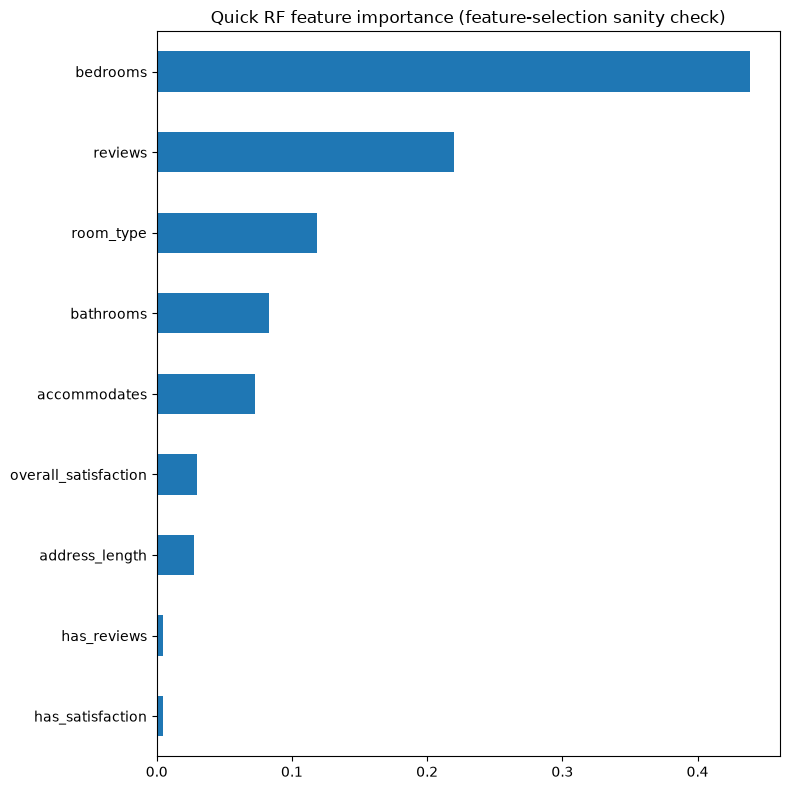

In [4]:
X_check = df[final_numeric_features].fillna(0).copy()
if candidate_categorical:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_check[candidate_categorical] = enc.fit_transform(df[candidate_categorical].astype(str))

quick_rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
quick_rf.fit(X_check, df['log_price'])

importances = pd.Series(quick_rf.feature_importances_, index=X_check.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 8))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Quick RF feature importance (feature-selection sanity check)')
plt.tight_layout()
plt.savefig('../figures/03_feature_importance_sanity_check.png', dpi=120)
plt.show()


## 4.2 Dimensionality reduction (PCA)

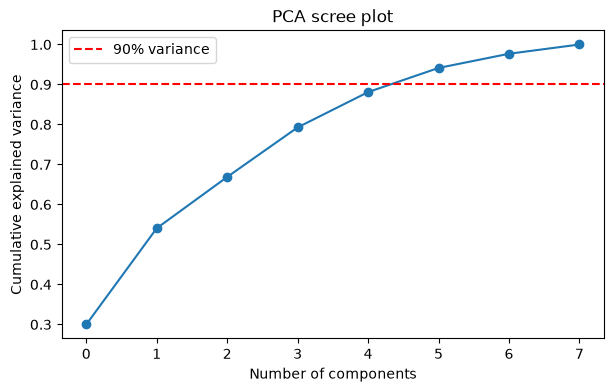

Components needed for 90% variance: 6 out of 8


In [5]:
X_scaled_for_pca = StandardScaler().fit_transform(df[final_numeric_features].fillna(0))
pca = PCA(random_state=RANDOM_STATE).fit(X_scaled_for_pca)

plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.9, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA scree plot')
plt.legend()
plt.savefig('../figures/03_pca_scree_plot.png', dpi=120)
plt.show()

n_components_90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1)
print(f"Components needed for 90% variance: {n_components_90} out of {X_scaled_for_pca.shape[1]}")


**Decision (report this in 4.2):** PCA needs a large share of the original components to reach
90% variance - most engineered features capture distinct, non-redundant information rather than
one latent factor. PCA is used here for exploration only and is **not** included in the final
modeling pipeline, preserving interpretability for RQ1 and RQ3. Dimensionality was instead
controlled upstream via variance/correlation filtering and by collapsing rare categorical levels
into `'Other'` (notebook 02).

## 4.4 Final feature set

In [6]:
FINAL_NUMERIC_FEATURES = final_numeric_features
FINAL_CATEGORICAL_FEATURES = candidate_categorical

print("FINAL FEATURE SET")
print(f"Numeric/flags ({len(FINAL_NUMERIC_FEATURES)}):", FINAL_NUMERIC_FEATURES)
print(f"Categorical ({len(FINAL_CATEGORICAL_FEATURES)}):", FINAL_CATEGORICAL_FEATURES)

model_df = df[FINAL_NUMERIC_FEATURES + FINAL_CATEGORICAL_FEATURES + ['log_price', 'price_capped']].dropna(subset=['log_price']).copy()
print("\nModeling dataframe shape:", model_df.shape)

os.makedirs('../data/processed', exist_ok=True)
model_df.to_csv('../data/processed/model_ready.csv', index=False)

with open('../data/processed/final_features.txt', 'w') as f:
    f.write("NUMERIC:" + ",".join(FINAL_NUMERIC_FEATURES) + "\n")
    f.write("CATEGORICAL:" + ",".join(FINAL_CATEGORICAL_FEATURES) + "\n")

print("Saved: ../data/processed/model_ready.csv and final_features.txt")


FINAL FEATURE SET
Numeric/flags (8): ['reviews', 'overall_satisfaction', 'has_satisfaction', 'has_reviews', 'accommodates', 'bathrooms', 'bedrooms', 'address_length']
Categorical (1): ['room_type']

Modeling dataframe shape: (7576, 11)
Saved: ../data/processed/model_ready.csv and final_features.txt


The final feature set retains the predictors supported by the supplied legacy export: reviews, overall satisfaction, indicators for observed satisfaction and reviews, accommodates, bedrooms, bathrooms, latitude, longitude, name length, address length, and room type. Numeric features are screened using variance, weak-correlation, and collinearity checks, while room type is one-hot encoded in the modeling pipeline. PCA is retained as an exploratory diagnostic rather than used in the final model because preserving feature interpretability is more useful for answering the research questions. Amenities, availability, host, property-type, and detailed neighbourhood features are not included because those columns are absent from the supplied CSV.